# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [64]:
import sys
import os
import random
import numpy as np
import torch
import torch.nn as nn # докинув для завдання
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 10 # поміняв на свій номер в журналі

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [4]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)

print("---TASK 1.1---")

arr1 = numbers.copy()
random.shuffle(arr1)
print("first:", random.randint(1, 100), arr1)

arr2 = numbers.copy()
random.shuffle(arr2)
print("second", random.randint(1, 100), arr2)

set_seed()
print("Seed зафіксовано:", SEED)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ окремим генеруванням

print("---TASK 1.2---")

set_seed()
arr3 = numbers.copy()
random.shuffle(arr3)
print("first call:", random.randint(1, 100), arr3)

set_seed()
arr4 = numbers.copy()
random.shuffle(arr4)
print("second call::", random.randint(1, 100), arr4)

# TODO: тепер ще двічі без проміжних викликів set_seed()

print("---TASK 1.3---")

arr5 = numbers.copy()
random.shuffle(arr5)
print("first call:", random.randint(1, 100), arr5)

arr6 = numbers.copy()
random.shuffle(arr6)
print("second call:", random.randint(1, 100), arr6)


---TASK 1.1---
first: 4 [8, 7, 2, 4, 5, 9, 0, 1, 3, 6]
second 28 [3, 9, 6, 5, 0, 8, 1, 2, 7, 4]
Seed зафіксовано: 10
---TASK 1.2---
first call: 36 [5, 2, 7, 1, 8, 4, 3, 6, 0, 9]
second call:: 36 [5, 2, 7, 1, 8, 4, 3, 6, 0, 9]
---TASK 1.3---
first call: 18 [3, 4, 5, 6, 1, 8, 9, 7, 0, 2]
second call: 85 [4, 1, 0, 7, 8, 2, 3, 6, 5, 9]


# --- Task 1.1 ---
 Результати кожного разу унікальні через використання системного часу як seed.
# --- Task 1.2 ---
Перед кожною генерацією стан генератора щоразу скидається до значення змінної `SEED`, тому результати дублюються.
# --- Task 1.3 ---
Працює псевдорандом - числа різні, але генеруються однаково, тому завжди буде 18 і 85 при `SEED = 10`

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [5]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [7]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [9]:
# TODO: zeros_arr = np.zeros((3, 4))
# TODO: sevens_arr = np.full((3, 4), 7)
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [11]:
# TODO: arange_arr = np.arange(0, 20, 2)
# TODO: linspace_arr = np.linspace(0, 1, 5)
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [15]:
# TODO: identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)
print("-----")
print(identity.ndim)
print(random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 9 1]
 [9 4 2]
 [6 7 8]]
-----
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [16]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [18]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [34]:
data = {
    'name': ['Vasya', 'Masya', 'Tasya', 'Kasya', 'Dasya'],
    'score': np.random.randint(1, 101, size=5)
}

df = pd.DataFrame(data) # додай тут дані для DataFrame

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
top = df[df['score'] > 80].sort_values(by='score', ascending=False)

if not top.empty:
    print(top)
else:
    print("no data")

    name  score
3  Kasya     91
0  Vasya     82
1  Masya     81


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [37]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"
df["grade"] = df["score"].apply(
    lambda s: "A" if s >= 90 else ("B" if s >= 75 else "C")
)
print(df)


    name  score grade
0  Vasya     82     B
1  Masya     81     B
2  Tasya     42     C
3  Kasya     91     A
4  Dasya     13     C


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [40]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t.shape, " | ", zeros_t.dtype)
print(sevens_t.shape, "| :", sevens_t.dtype)


torch.Size([2, 3])  |  torch.float32
torch.Size([2, 3]) | : torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [42]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [47]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print("--- From list ---")
print("Tensor:\n", from_list)
print("Shape:", from_list.shape)
print("Data Type:", from_list.dtype)
print("Ndim:", from_list.ndim)

print("\n--- Random ---")
print("Tensor:\n", random_t)
print("Shape:", random_t.shape)
print("Data Type:", random_t.dtype)
print("Ndim:", random_t.ndim)


--- From list ---
Tensor:
 tensor([[1, 2],
        [3, 4]])
Shape: torch.Size([2, 2])
Data Type: torch.int64
Ndim: 2

--- Random ---
Tensor:
 tensor([[0.9502, 0.4655, 0.9314],
        [0.6533, 0.8914, 0.8988],
        [0.3955, 0.3546, 0.5752]])
Shape: torch.Size([3, 3])
Data Type: torch.float32
Ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [49]:
n = 5.0

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
# надрукувати x.grad.item() і порівняти з 2 * n

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

auto_grad = x.grad.item()
analytical_grad = 2 * n

print(auto_grad)
print(analytical_grad)
print(auto_grad == analytical_grad)


10.0
10.0
True


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [51]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
#   loss = (x - 3) ** 2 + 5
#   loss.backward()
#   під torch.no_grad(): x -= lr * x.grad
#   x.grad.zero_()

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad(): x -= lr * x.grad
    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

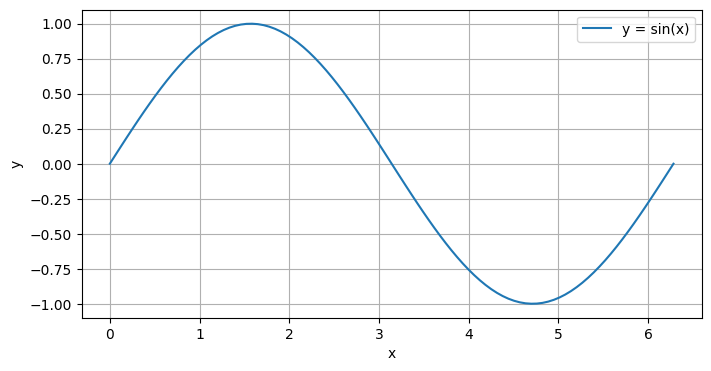

In [55]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()

xs = np.linspace(0, 2 * np.pi, 100)
ys = np.sin(xs)

plt.figure(figsize=(8, 4))
plt.plot(xs, ys, label="y = sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

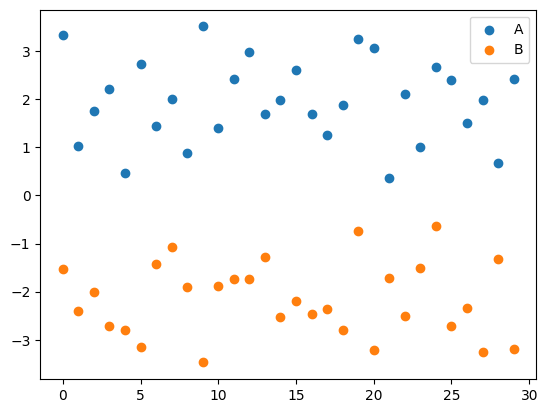

In [56]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()

plt.scatter(range(len(group_a)), group_a, color="C0", label="A")
plt.scatter(range(len(group_b)), group_b, color="C1", label="B")

plt.legend()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [57]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

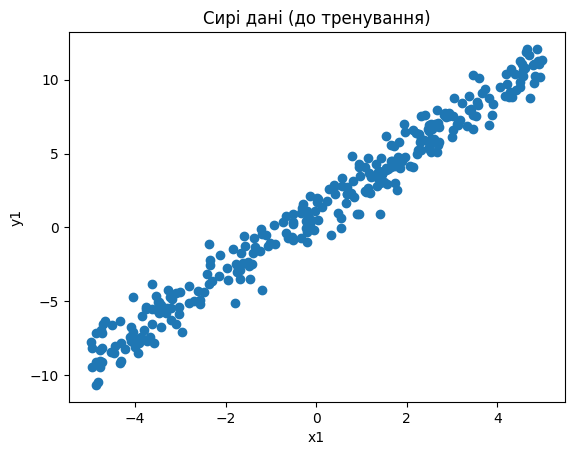

In [58]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"

plt.scatter(x1, y1)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [60]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...

perm = torch.randperm(TASK1_N)

train_size = int(0.70 * TASK1_N)
val_size = int(0.15 * TASK1_N)

train_idx = perm[:train_size]
val_idx = perm[train_size:train_size + val_size]
test_idx = perm[train_size + val_size:]

x_train1, y_train1 = x1[train_idx], y1[train_idx]
x_val1, y_val1 = x1[val_idx], y1[val_idx]
x_test1, y_test1 = x1[test_idx], y1[test_idx]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [61]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=32.210381  w=1.6713 (true 2.0)  b=0.1892 (true 1.0)
epoch   30  loss=0.877051  w=2.0425 (true 2.0)  b=0.9688 (true 1.0)
epoch   60  loss=0.875562  w=2.0413 (true 2.0)  b=1.0022 (true 1.0)
epoch   90  loss=0.875559  w=2.0412 (true 2.0)  b=1.0037 (true 1.0)
epoch   99  loss=0.875559  w=2.0412 (true 2.0)  b=1.0037 (true 1.0)


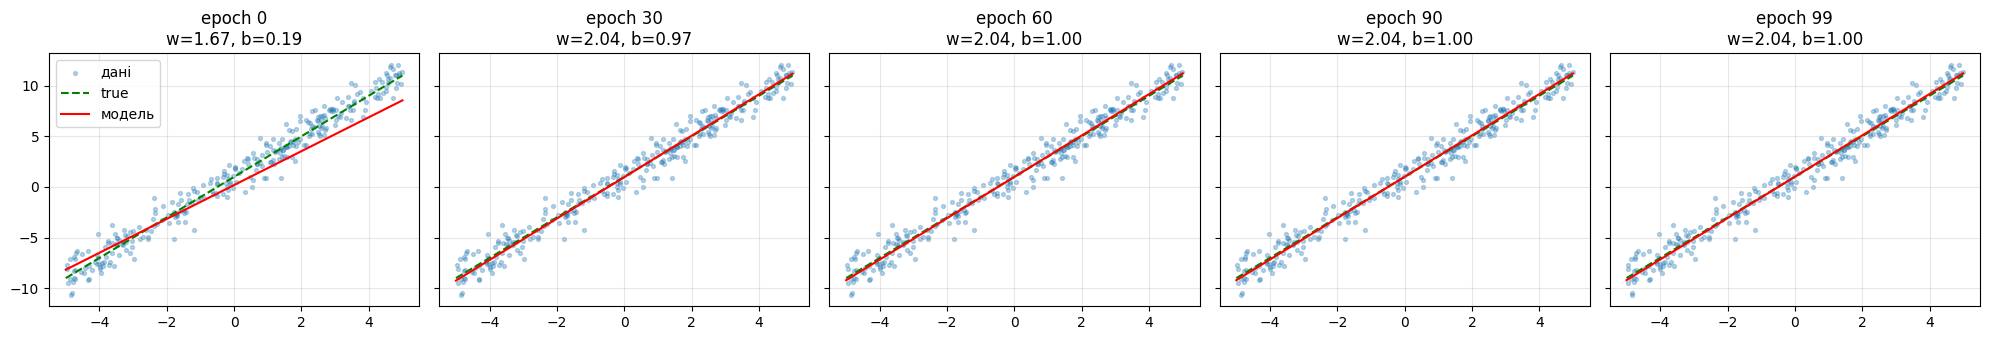

In [62]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

### Матчмейкінг у Street Fighter 6 (EU Server, робочий день)

У робочий день вдень на європейських серверах відносно низький онлайн. Більшість гравців середнього рівня перебувають на роботі чи навчанні, а у грі залишаються переважно «задроти» з високим рейтингом.

matchmaking шукає протиборця з максимально близьким рейтингом. Якщо відповідного суперника немає поруч, із часом пошуку алгоритм вимушено розширює допустимий діапазон рейтингів.

**Формулювання лінійної залежності:**
$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

- **$x$ (`search_time_min`):** Час пошуку гри в хвилинах ($0.5 \dots 10.0$ хв).
- **$y$ (`skill_diff_mr`):** Абсолютна різниця в силі / рейтингу MR між вами та знайденим суперником.

**Обґрунтування параметрів ($w$, $b$):**
1. **$w = 150.0$ (Slope / Нахил):** Кожна додаткова хвилина очікування розширює коридор пошуку орієнтовно на 150 MR. Наприклад, за 5 хвилин пошуку шанс зустріти суперника, який сильніший/слабший на ~750–800 MR зростає практично до 100%.
2. **$b = 50.0$ (Bias / Зсув):** Навіть при миттєвому підборі (0 хвилин очікування) існує базова розбіжність у рейтингу близько 50 MR через локальні обмеження та пінг.
3. **Шум $\varepsilon \sim \mathcal{N}(0, 80^2)$:** Випадкові фактори (хтось саме зайшов у чергу, географічне розташування, пінг).

In [80]:
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

csv_filepath = os.path.join(ARTIFACT_DIR, 'sf6_matchmaking.csv')

torch.manual_seed(42)
np.random.seed(42)

def generate_and_save_data(filepath, N=500):
    x_search_time = torch.empty(N, 1).uniform_(0.5, 10.0)
    TRUE_W, TRUE_B = 150.0, 50.0
    noise = torch.randn(N, 1) * 80.0

    y_skill_diff = TRUE_W * x_search_time + TRUE_B + noise

    df = pd.DataFrame({
        'search_time_min': x_search_time.squeeze().numpy(),
        'skill_diff_mr': y_skill_diff.squeeze().numpy()
    })

    df.to_csv(filepath, index=False)
    print(f"[+] Data generated and saved to '{filepath}'.")
    return filepath

def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    x = torch.tensor(df['search_time_min'].values, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(df['skill_diff_mr'].values, dtype=torch.float32).unsqueeze(1)
    return x, y

def split_data(x, y, train_ratio=0.70, val_ratio=0.15):
    N = len(x)
    perm = torch.randperm(N)
    train_size = int(train_ratio * N)
    val_size = int(val_ratio * N)
    train_idx = perm[:train_size]
    val_idx = perm[train_size:train_size + val_size]
    test_idx = perm[train_size + val_size:]
    return (x[train_idx], y[train_idx]), (x[val_idx], y[val_idx]), (x[test_idx], y[test_idx])

def train_linear_regression(x_train, y_train, x_val, y_val, epochs=200, lr=0.01):
    model = nn.Linear(in_features=1, out_features=1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    x_line = torch.linspace(0, 10, 100).unsqueeze(1)
    snapshots = []

    print("\n--- Starting Training ---")
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        loss.backward()
        optimizer.step()

        if epoch in [0, 20, 50, 100, 199]:
            model.eval()
            with torch.no_grad():
                y_line_pred = model(x_line)
                snapshots.append((epoch, model.weight.item(), model.bias.item(), y_line_pred.clone()))

        if (epoch + 1) % 50 == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(x_val)
                val_loss = loss_fn(val_pred, y_val)
            print(f"Epoch {epoch+1:3d} | Train Loss: {loss.item():.2f} | Val Loss: {val_loss.item():.2f} | "
                  f"w: {model.weight.item():.2f}, b: {model.bias.item():.2f}")

    return model, snapshots, x_line

def evaluate_model(model, x_test, y_test):
    model.eval()
    loss_fn = nn.MSELoss()
    with torch.no_grad():
        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)
        mae = torch.mean(torch.abs(test_pred - y_test))

    print("\n--- Test Set Evaluation ---")
    print(f"Test MSE Loss: {test_loss.item():.2f}")
    print(f"Test MAE: {mae.item():.2f} MR")
    return test_loss.item(), mae.item()

csv_file = generate_and_save_data(csv_filepath, N=500)
x, y = load_and_preprocess_data(csv_file)
(x_train, y_train), (x_val, y_val), (x_test, y_test) = split_data(x, y)

model, snapshots, x_line = train_linear_regression(x_train, y_train, x_val, y_val, epochs=200, lr=0.01)
evaluate_model(model, x_test, y_test)

[+] Data generated and saved to '/content/drive/MyDrive/ai_systems/lab1/sf6_matchmaking.csv'.

--- Starting Training ---
Epoch   1 | Train Loss: 819561.62 | Val Loss: 93724.88 | w: 104.16, b: 16.73
Epoch  50 | Train Loss: 6408.15 | Val Loss: 6167.11 | w: 153.25, b: 29.43
Epoch 100 | Train Loss: 6373.37 | Val Loss: 6152.22 | w: 152.61, b: 33.53
Epoch 150 | Train Loss: 6351.14 | Val Loss: 6145.64 | w: 152.11, b: 36.80
Epoch 200 | Train Loss: 6336.93 | Val Loss: 6143.79 | w: 151.71, b: 39.42

--- Test Set Evaluation ---
Test MSE Loss: 4585.30
Test MAE: 55.54 MR


(4585.29736328125, 55.53828048706055)

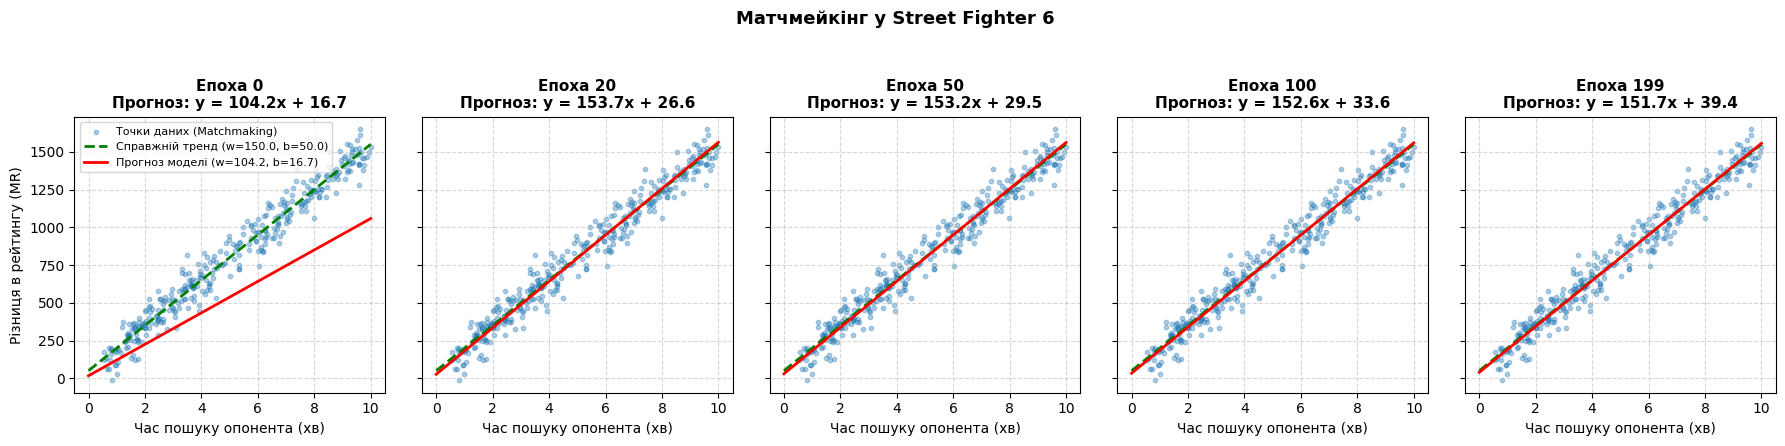

In [81]:
TASK1_TRUE_W, TASK1_TRUE_B = 150.0, 50.0
y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 4.2), sharey=True)

for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.35, color='#1f77b4', label="Точки даних (Matchmaking)")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", linewidth=2, label=f"Справжній тренд (w={TASK1_TRUE_W}, b={TASK1_TRUE_B})")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", linewidth=2, label=f"Прогноз моделі (w={w:.1f}, b={b:.1f})")

    ax.set_title(f"Епоха {epoch}\nПрогноз: y = {w:.1f}x + {b:.1f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Час пошуку опонента (хв)", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].set_ylabel("Різниця в рейтингу (MR)", fontsize=10)
axes[0].legend(loc="upper left", fontsize=8)

plt.suptitle("Матчмейкінг у Street Fighter 6", y=1.05, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [82]:
model_save_path = os.path.join(ARTIFACT_DIR, "model.pt")
torch.save(model.state_dict(), model_save_path)

**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [84]:
!pip install -q gradio
import gradio as gr

ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"
model_save_path = os.path.join(ARTIFACT_DIR, "model.pt")

model = nn.Linear(in_features=1, out_features=1)
model.load_state_dict(torch.load(model_save_path))
model.eval()  # Переводимо у режим інференсу

def predict_skill_diff(search_time_min):
    x_input = torch.tensor([[float(search_time_min)]], dtype=torch.float32)

    with torch.no_grad():
        prediction = model(x_input).item()

    predicted_mr = max(0.0, prediction)
    return f"{predicted_mr:.1f} MR"
demo = gr.Interface(
    fn=predict_skill_diff,
    inputs=gr.Number(label="Час пошуку гри в хвилинах", value=5.0),
    outputs=gr.Textbox(label="Очікувана різниця в рейтингу")
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d32a152617080ae3be.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d32a152617080ae3be.gradio.live


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```